In [1]:
%pip install pandas requests gitpython tiktoken python-hcl2 matplotlib seaborn datasets tqdm ipywidgets func_timeout


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import subprocess
import os

# Create a copy of the notebook's environment variables
env = os.environ.copy()

# Inject the standard Apple Silicon Homebrew binary path into the current environment
env["PATH"] = f"/opt/homebrew/bin:{env['PATH']}"

# Run the command with the updated PATH map
subprocess.run("tflint", shell=True, env=env)

CompletedProcess(args='tflint', returncode=0)

In [3]:
# %%
# ── 1. Configuration ──────────────────────────────────────────────────────────
import os
import pathlib
import tiktoken

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR       = pathlib.Path('./iac_benchmark')          
REPOS_DIR      = BASE_DIR / 'repos'                       
DATASET_DIR    = BASE_DIR / 'dataset'                     
MULTI_ROOT_DIR = BASE_DIR / 'scenarios'                   # Folders for each scenario

for d in [REPOS_DIR, DATASET_DIR, MULTI_ROOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── GitHub API Token ──────────────────────────────────────────────────────────
GITHUB_TOKEN = os.environ.get('GITHUB_TOKEN', '')
GH_HEADERS   = {'Authorization': f'token {GITHUB_TOKEN}'} if GITHUB_TOKEN else {}

# ── Filter Thresholds (No Max LoC) ────────────────────────────────────────────
MIN_LOC    = 5
MAX_TOKENS = 8_000

# ── Tokenizer ─────────────────────────────────────────────────────────────────
TOKENIZER = tiktoken.get_encoding('cl100k_base')

print('✅ Configuration loaded.')
print(f'  Workspace : {BASE_DIR.resolve()}')
print(f'  Limits    : MIN_LOC={MIN_LOC}, MAX_TOKENS={MAX_TOKENS}')

✅ Configuration loaded.
  Workspace : /Users/iksena/Documents/research/data_analysis/iac_benchmark
  Limits    : MIN_LOC=5, MAX_TOKENS=8000


In [4]:
# %%
# ── 2. Repository Registry ────────────────────────────────────────────────────
# Minimal registry containing only the slug and optional notes.
REPO_REGISTRY = [
    {'slug': 'hashicorp/terraform-guides', 'notes': 'Official HashiCorp usage patterns'},
    {'slug': 'aws-samples/aws-terraform-best-practices', 'notes': 'AWS architecture best practices'},
    {'slug': 'terraform-aws-modules/terraform-aws-vpc', 'notes': 'Deployable VPC configurations'},
    {'slug': 'futurice/terraform-examples', 'notes': ''},
    {'slug': 'brokedba/terraform-examples', 'notes': ''},
    {'slug': 'ContainerSolutions/terraform-examples', 'notes': 'Simple, idiomatic examples'},
    {'slug': 'antonputra/tutorials', 'notes': 'Beginner-friendly single-file examples'},
    {'slug': 'ned1313/terraform-tuesdays', 'notes': ''},
    {'slug': 'alfonsof/terraform-aws-examples', 'notes': ''},
    {'slug': 'databricks/terraform-databricks-examples', 'notes': ''},
    {'slug': 'aws-cloudformation/iac-model-evaluation', 'notes': ''},
    {'slug': 'gitmurali/terraform-aws-snippets', 'notes': ''},
    {'slug': 'ovotech/terraform-testing-samples', 'notes': ''},
    {'slug': 'garutilorenzo/aws-terraform-examples', 'notes': ''},
    {'slug': 'ValeriiVasianovych/terraform-iac', 'notes': ''},
    {'slug': 'zealvora/terraform-beginner-to-advanced-resource', 'notes': ''},
    {'slug': 'wardviaene/terraform-course', 'notes': ''},
    {'slug': 'diodonfrost/terraform-aws-examples', 'notes': ''},
    {'slug': 'brikis98/terraform-up-and-running-code', 'notes': ''},
    {'slug': 'aws-samples/cict-terraform-scripts', 'notes': ''},
    {'slug': 'stack72/terraform-examples', 'notes': ''},
    {'slug': 'Tianyi2/IRIS', 'notes': ''},
]

print(f'✅ Registered {len(REPO_REGISTRY)} repositories.')

✅ Registered 22 repositories.


In [5]:
# %%
# ── 3. Ethical Licence Filter ─────────────────────────────────────────────────
import pandas as pd
import requests

LICENCE_CACHE = DATASET_DIR / 'licence_cache.csv'
ALLOWED_SPDX  = {
    'MIT', 'MIT-0', 'Apache-2.0', 'BSD-2-Clause', 'BSD-3-Clause',
    'ISC', 'MPL-2.0', 'CC0-1.0', 'Unlicense', 'WTFPL'
}

def fetch_licence(slug: str) -> dict:
    url = f'https://api.github.com/repos/{slug}/license'
    r = requests.get(url, headers=GH_HEADERS, timeout=10)
    if r.status_code == 200:
        return r.json().get('license', {}).get('spdx_id', 'NOASSERTION')
    return 'NONE'

if LICENCE_CACHE.exists():
    _cache = pd.read_csv(LICENCE_CACHE, index_col='slug')['spdx'].to_dict()
    print('✅ Loaded licence cache from disk.')
else:
    _cache = {}

approved_repos = []

print('Checking repository licences...')
for repo in REPO_REGISTRY:
    slug = repo['slug']
    spdx = _cache.get(slug) or fetch_licence(slug)
    _cache[slug] = spdx
    
    if spdx in ALLOWED_SPDX:
        repo['licence'] = spdx
        approved_repos.append(repo)
        print(f"  [OK] {slug} ({spdx})")
    else:
        print(f"  [SKIP] {slug} ({spdx} not permitted)")

# Save cache
pd.DataFrame(list(_cache.items()), columns=['slug', 'spdx']).to_csv(LICENCE_CACHE, index=False)
print(f'\n✅ Approved {len(approved_repos)} repositories.')

✅ Loaded licence cache from disk.
Checking repository licences...
  [OK] hashicorp/terraform-guides (MPL-2.0)
  [SKIP] aws-samples/aws-terraform-best-practices (NOASSERTION not permitted)
  [OK] terraform-aws-modules/terraform-aws-vpc (Apache-2.0)
  [OK] futurice/terraform-examples (MIT)
  [SKIP] brokedba/terraform-examples (GPL-3.0 not permitted)
  [SKIP] ContainerSolutions/terraform-examples (NONE not permitted)
  [OK] antonputra/tutorials (MIT)
  [OK] ned1313/terraform-tuesdays (MIT)
  [OK] alfonsof/terraform-aws-examples (MIT)
  [SKIP] databricks/terraform-databricks-examples (NOASSERTION not permitted)
  [OK] aws-cloudformation/iac-model-evaluation (MIT-0)
  [OK] gitmurali/terraform-aws-snippets (MIT)
  [OK] ovotech/terraform-testing-samples (Apache-2.0)
  [SKIP] garutilorenzo/aws-terraform-examples (GPL-3.0 not permitted)
  [OK] ValeriiVasianovych/terraform-iac (MIT)
  [SKIP] zealvora/terraform-beginner-to-advanced-resource (NONE not permitted)
  [SKIP] wardviaene/terraform-cours

In [6]:
# %%
# ── 4. Fetch IaC-Eval Dataset ─────────────────────────────────────────────────
from datasets import load_dataset

print('Downloading autoiac-project/iac-eval from HuggingFace...')
try:
    # Load directly from HF datasets library
    ds = load_dataset('autoiac-project/iac-eval', split='test')
    df_iac_eval = ds.to_pandas()
    print(f'✅ Loaded IaC-Eval: {len(df_iac_eval)} scenarios.')
except Exception as e:
    print(f"❌ Failed to load dataset: {e}")
    # Create empty dataframe to prevent downstream errors if HF is unreachable
    df_iac_eval = pd.DataFrame()

✅ Loaded IaC-Eval: 458 scenarios.


In [7]:
# %%
# ── 5. Clone / Pull Repositories ──────────────────────────────────────────────
import git

def clone_or_pull(slug: str, dest: pathlib.Path) -> bool:
    url = f'https://github.com/{slug}.git'
    try:
        if dest.exists():
            git.Repo(dest).remotes.origin.pull(depth=1)
        else:
            git.Repo.clone_from(url, dest, depth=1, single_branch=True)
        return True
    except Exception as e:
        print(f'  ⚠️ {slug}: {e}')
        return False

print('Cloning approved repositories...')
for repo in approved_repos:
    dest = REPOS_DIR / repo['slug'].replace('/', '__')
    repo['local_path'] = str(dest)
    status = '✅' if clone_or_pull(repo['slug'], dest) else '❌'
    print(f'  {status} {repo["slug"]}')

Cloning approved repositories...
  ✅ hashicorp/terraform-guides
  ✅ terraform-aws-modules/terraform-aws-vpc
  ✅ futurice/terraform-examples
  ✅ antonputra/tutorials
  ✅ ned1313/terraform-tuesdays
  ✅ alfonsof/terraform-aws-examples
  ✅ aws-cloudformation/iac-model-evaluation
  ✅ gitmurali/terraform-aws-snippets
  ✅ ovotech/terraform-testing-samples
  ✅ ValeriiVasianovych/terraform-iac
  ✅ brikis98/terraform-up-and-running-code
  ✅ aws-samples/cict-terraform-scripts
  ✅ Tianyi2/IRIS


In [8]:
# import shutil

# # Delete the bloated cache
# # if PARSE_CACHE_FILE.exists():
# #     PARSE_CACHE_FILE.unlink()

# # Delete the duplicated scenario folders
# if MULTI_ROOT_DIR.exists():
#     shutil.rmtree(MULTI_ROOT_DIR)
# MULTI_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# print("🗑️ Cleanup complete! Ready for deterministic IDs.")

In [9]:
# %%
# ── 6. Collect GitHub Scenarios (Optimized) ───────────────────────────────────
import shutil
import hashlib
import re
import pathlib

raw_scenarios = []
SKIP_RE = re.compile(r'(^|/)(\.|__pycache__|\.git|\.terraform|testdata|tests?|fixtures?|vendor)(/|$)', re.IGNORECASE)

print('Collecting unique scenarios from repositories...')
new_copied = 0
already_cached = 0

for repo in approved_repos:
    if 'local_path' not in repo:
        continue
        
    repo_path = pathlib.Path(repo['local_path'])
    tf_files = list(repo_path.rglob('*.tf'))
    
    parent_dirs = set(tf.parent for tf in tf_files if not SKIP_RE.search(str(tf.relative_to(repo_path))))
    
    for p in parent_dirs:
        # Create a deterministic ID based on the repo name and relative folder path
        rel_path = str(p.relative_to(repo_path))
        unique_string = f"{repo['slug']}::{rel_path}"
        scenario_id = f"gh_{hashlib.md5(unique_string.encode()).hexdigest()[:8]}"
        
        dest_dir = MULTI_ROOT_DIR / scenario_id
        
        # ── CACHE CHECK ──
        # Only copy files if the directory doesn't exist or is empty
        if not dest_dir.exists() or not any(dest_dir.glob('*.tf')):
            dest_dir.mkdir(parents=True, exist_ok=True)
            for f in p.glob('*.tf'):
                if f.is_file():  
                    shutil.copy2(f, dest_dir / f.name)
            new_copied += 1
        else:
            already_cached += 1
            
        raw_scenarios.append({
            'scenario_id': scenario_id,
            'source': repo['slug'],
            'folder_path': str(dest_dir)
        })

print(f'✅ Collected {len(raw_scenarios)} folder-based scenarios from GitHub.')
print(f'  📁 Newly copied : {new_copied}')
print(f'  ⚡ Skipped (cached) : {already_cached}')

✅ Collected 40660 folder-based scenarios from GitHub.
  📁 Newly copied : 1
  ⚡ Skipped (cached) : 40659


In [10]:
# %%
# ── 7. Persist IaC-Eval as Folders ────────────────────────────────────────────
import hashlib

if not df_iac_eval.empty:
    print('Persisting IaC-Eval single-file templates to independent folders...')
    
    for idx, row in df_iac_eval.iterrows():
        content = str(row.get('Reference output', '')).strip()
        if not content:
            continue
            
        # Create deterministic ID based on the index and content hash
        unique_string = f"iaceval_{idx}_{hashlib.md5(content.encode()).hexdigest()}"
        scenario_id = f"iaceval_{hashlib.md5(unique_string.encode()).hexdigest()[:8]}"
        
        dest_dir = MULTI_ROOT_DIR / scenario_id
        dest_dir.mkdir(parents=True, exist_ok=True)
        
        (dest_dir / "main.tf").write_text(content, encoding='utf-8')
        
        raw_scenarios.append({
            'scenario_id': scenario_id,
            'source': 'autoiac-project/iac-eval',
            'folder_path': str(dest_dir)
        })
        
    print(f'✅ Integrated {len(df_iac_eval)} IaC-Eval scenarios.')
else:
    print('⚠️ Skipped IaC-Eval persist (dataframe was empty).')

# Deduplicate raw_scenarios just in case
raw_scenarios = {rec['scenario_id']: rec for rec in raw_scenarios}.values()
raw_scenarios = list(raw_scenarios)

print(f'\nTotal aggregated scenarios ready for parsing: {len(raw_scenarios)}')

Persisting IaC-Eval single-file templates to independent folders...
✅ Integrated 458 IaC-Eval scenarios.

Total aggregated scenarios ready for parsing: 41117


In [11]:
# %%
# ── 7.5. Fetch TerraDS Dataset from Zenodo (Optimized & Resumable) ────────────
import requests
import zipfile
import tarfile
import pathlib
import hashlib
import shutil
import re
import pandas as pd
from tqdm.notebook import tqdm

ZENODO_RECORD_ID = "14217386"
TERRADS_DIR = DATASET_DIR / "TerraDS"
TERRADS_DIR.mkdir(parents=True, exist_ok=True)

TERRADS_CACHE_FILE = DATASET_DIR / 'terrads_scenarios.csv'
TERRADS_DONE_FLAG = DATASET_DIR / '.terrads_done'
TARGET_ARCHIVE_RE = re.compile(r"^TerraDS.*\.(tar\.gz|tar\.xz|zip)$", re.IGNORECASE)

# ── 0. Fast-Path: Load from Cache if Already Completed ────────────────────────
if TERRADS_DONE_FLAG.exists() and TERRADS_CACHE_FILE.exists():
    print("✅ TerraDS integration previously completed! Loading directly from cache...")
    df_terrads_cache = pd.read_csv(TERRADS_CACHE_FILE)
    terrads_records = df_terrads_cache.to_dict('records')
    
    # Safely extend raw_scenarios
    existing_ids = {r["scenario_id"] for r in raw_scenarios}
    for rec in terrads_records:
        if rec["scenario_id"] not in existing_ids:
            raw_scenarios.append(rec)
            existing_ids.add(rec["scenario_id"])
            
    print(f"✅ Integrated {len(terrads_records)} TerraDS scenarios from cache.")
    print(f"\nTotal aggregated scenarios now ready for parsing: {len(raw_scenarios)}")

else:
    # ── Shared helpers ────────────────────────────────────────────────────────
    def _is_valid_archive(path: pathlib.Path, min_bytes: int = 1_000_000) -> bool:
        if not path.exists() or path.stat().st_size < min_bytes:
            return False
        try:
            if path.suffix == ".zip":
                with zipfile.ZipFile(path, "r"): return True
            else:
                with tarfile.open(path, "r:*"): return True
        except Exception:
            return False

    def _safe_members(tar: tarfile.TarFile, dest: pathlib.Path):
        root = dest.resolve()
        for member in tar.getmembers():
            member_path = (dest / member.name).resolve()
            try:
                member_path.relative_to(root)
            except ValueError:
                continue
            yield member

    def _extract_archive(archive_path: pathlib.Path, dest: pathlib.Path):
        if str(archive_path).endswith(".zip"):
            with zipfile.ZipFile(archive_path, "r") as z:
                z.extractall(dest)
        else:
            with tarfile.open(archive_path, "r:*") as tar_ref:
                tar_ref.extractall(dest, members=_safe_members(tar_ref, dest))

    # ── Fetch Zenodo metadata ─────────────────────────────────────────────────
    print(f"Fetching metadata for Zenodo record {ZENODO_RECORD_ID}...")
    api_url = f"https://zenodo.org/api/records/{ZENODO_RECORD_ID}"
    response = requests.get(api_url, timeout=15)
    response.raise_for_status()
    record_data = response.json()

    archive_url  = None
    archive_name = None
    expected_md5 = None

    for file_meta in record_data.get("files", []):
        fname = file_meta.get("key") or file_meta.get("filename", "")
        if TARGET_ARCHIVE_RE.match(fname):
            archive_url  = file_meta["links"]["self"]
            archive_name = fname
            checksum_raw = file_meta.get("checksum", "")
            expected_md5 = checksum_raw.replace("md5:", "") if checksum_raw.startswith("md5:") else None
            break

    if not archive_url:
        print("❌ Could not find the TerraDS source-code archive in the Zenodo record.")
    else:
        archive_path = TERRADS_DIR / archive_name
        archive_tmp  = archive_path.with_suffix(".tmp")

        if "raw_scenarios" not in globals() or not isinstance(raw_scenarios, list):
            raw_scenarios = []

        # ── 1. Download Archive ───────────────────────────────────────────────
        if _is_valid_archive(archive_path):
            print(f"✅ Archive {archive_name} already exists and is valid.")
        else:
            for stale in (archive_path, archive_tmp):
                if stale.exists():
                    stale.unlink()

            print(f"Downloading {archive_name} from Zenodo...")
            session = requests.Session()
            with session.get(archive_url, stream=True, timeout=(10, 120), allow_redirects=True) as r:
                r.raise_for_status()
                total_size = int(r.headers.get("Content-Length", 0))
                bytes_written = 0
                with open(archive_tmp, "wb") as f:
                    for chunk in r.iter_content(chunk_size=65_536):
                        if chunk:
                            f.write(chunk)
                            bytes_written += len(chunk)
                            if total_size:
                                pct = bytes_written / total_size * 100
                                print(f"  {bytes_written:,} / {total_size:,} B ({pct:.1f}%)", end="\r")
            if total_size: print()

            if expected_md5:
                print("Verifying MD5 checksum...")
                h = hashlib.md5()
                with open(archive_tmp, "rb") as f:
                    for chunk in iter(lambda: f.read(65_536), b""):
                        h.update(chunk)
                if h.hexdigest() != expected_md5:
                    archive_tmp.unlink()
                    raise ValueError("Checksum mismatch! Temp file deleted — re-run to retry.")

            archive_tmp.rename(archive_path)
            print("✅ Download complete.")

        # ── 2. Extract Outer & Inner Archives ─────────────────────────────────
        extract_dir = TERRADS_DIR / "extracted"
        if not extract_dir.exists():
            print("Extracting outer archive...")
            extract_dir.mkdir(parents=True, exist_ok=True)
            _extract_archive(archive_path, extract_dir)
            print("✅ Outer extraction complete.")

        repos_dir = extract_dir / "TerraDS"
        if not repos_dir.exists(): repos_dir = extract_dir 

        inner_archives = sorted(repos_dir.glob("*.tar.gz")) + sorted(repos_dir.glob("*.tar.xz"))
        if inner_archives:
            def _repo_dest(inner: pathlib.Path) -> pathlib.Path:
                return repos_dir / inner.name.replace(".tar.gz", "").replace(".tar.xz", "")

            remaining = [a for a in inner_archives if not _repo_dest(a).exists()]
            if remaining:
                print(f"Extracting {len(remaining):,} inner repo archives...")
                for i, inner in enumerate(remaining, start=1):
                    repo_dest = _repo_dest(inner)
                    repo_dest.mkdir(exist_ok=True)
                    try:
                        _extract_archive(inner, repo_dest)
                    except Exception as exc:
                        shutil.rmtree(repo_dest, ignore_errors=True)
                    if i % 5_000 == 0:
                        print(f"  ... {i:,} / {len(remaining):,} repos extracted")

        # ── 3. Collect Scenarios (Resumable) ──────────────────────────────────
        _SKIP_EXACT = frozenset({".git", ".terraform", "__pycache__", "vendor", "testdata"})
        _SKIP_RE    = re.compile(r"^(tests?|fixtures?|\..+)$", re.IGNORECASE)

        def _should_skip(path: pathlib.Path, base: pathlib.Path) -> bool:
            try: parts = path.relative_to(base).parts
            except ValueError: return True
            return any(p in _SKIP_EXACT or bool(_SKIP_RE.fullmatch(p)) for p in parts)

        print("Scanning for .tf files...")
        tf_files = [tf for tf in repos_dir.rglob("*.tf") if not _should_skip(tf.parent, repos_dir)]
        parent_dirs = {tf.parent for tf in tf_files}
        print(f"  Found {len(tf_files):,} .tf files across {len(parent_dirs):,} module directories.")

        # Load partial cache if interrupted previously
        if TERRADS_CACHE_FILE.exists():
            terrads_cached_records = pd.read_csv(TERRADS_CACHE_FILE).to_dict('records')
            terrads_processed_ids = {r["scenario_id"] for r in terrads_cached_records}
            print(f"  Resuming from cache: {len(terrads_processed_ids)} scenarios already processed.")
        else:
            terrads_cached_records = []
            terrads_processed_ids = set()

        terrads_new = 0

        for i, p in enumerate(tqdm(parent_dirs, desc="Integrating TerraDS")):
            rel_path = str(p.relative_to(repos_dir))
            unique_string = f"terrads::{rel_path}"
            scenario_id = f"terrads_{hashlib.md5(unique_string.encode()).hexdigest()[:12]}"

            if scenario_id in terrads_processed_ids:
                continue

            dest_dir = MULTI_ROOT_DIR / scenario_id

            if not dest_dir.exists() or not any(dest_dir.glob("*.tf")):
                dest_dir.mkdir(parents=True, exist_ok=True)
                for f in p.glob("*.tf"):
                    if f.is_file():
                        shutil.copy2(f, dest_dir / f.name)

            rec = {
                "scenario_id": scenario_id,
                "source": "Zenodo/TerraDS",
                "folder_path": str(dest_dir),
            }
            terrads_cached_records.append(rec)
            terrads_processed_ids.add(scenario_id)
            terrads_new += 1

            # Save progress periodically
            if terrads_new % 1000 == 0:
                pd.DataFrame(terrads_cached_records).to_csv(TERRADS_CACHE_FILE, index=False)

        # ── 4. Finalise ───────────────────────────────────────────────────────
        pd.DataFrame(terrads_cached_records).to_csv(TERRADS_CACHE_FILE, index=False)
        TERRADS_DONE_FLAG.touch()  # Mark as fully complete!
        
        # Merge into global raw_scenarios
        existing_global_ids = {r["scenario_id"] for r in raw_scenarios}
        for rec in terrads_cached_records:
            if rec["scenario_id"] not in existing_global_ids:
                raw_scenarios.append(rec)
                existing_global_ids.add(rec["scenario_id"])

        print(f"✅ Integrated TerraDS scenarios!")
        print(f"  📁 Newly copied: {terrads_new}")
        print(f"\nTotal aggregated scenarios now ready for parsing: {len(raw_scenarios)}")

✅ TerraDS integration previously completed! Loading directly from cache...
✅ Integrated 269919 TerraDS scenarios from cache.

Total aggregated scenarios now ready for parsing: 311036


✅ Loaded 311036 previously parsed scenario IDs from cache.
Calculating LoC, tokens, and AST features for 0 new scenarios...

Filtering Results:
  Original count : 311036
  Filtered count : 300642 (dropped 10394)


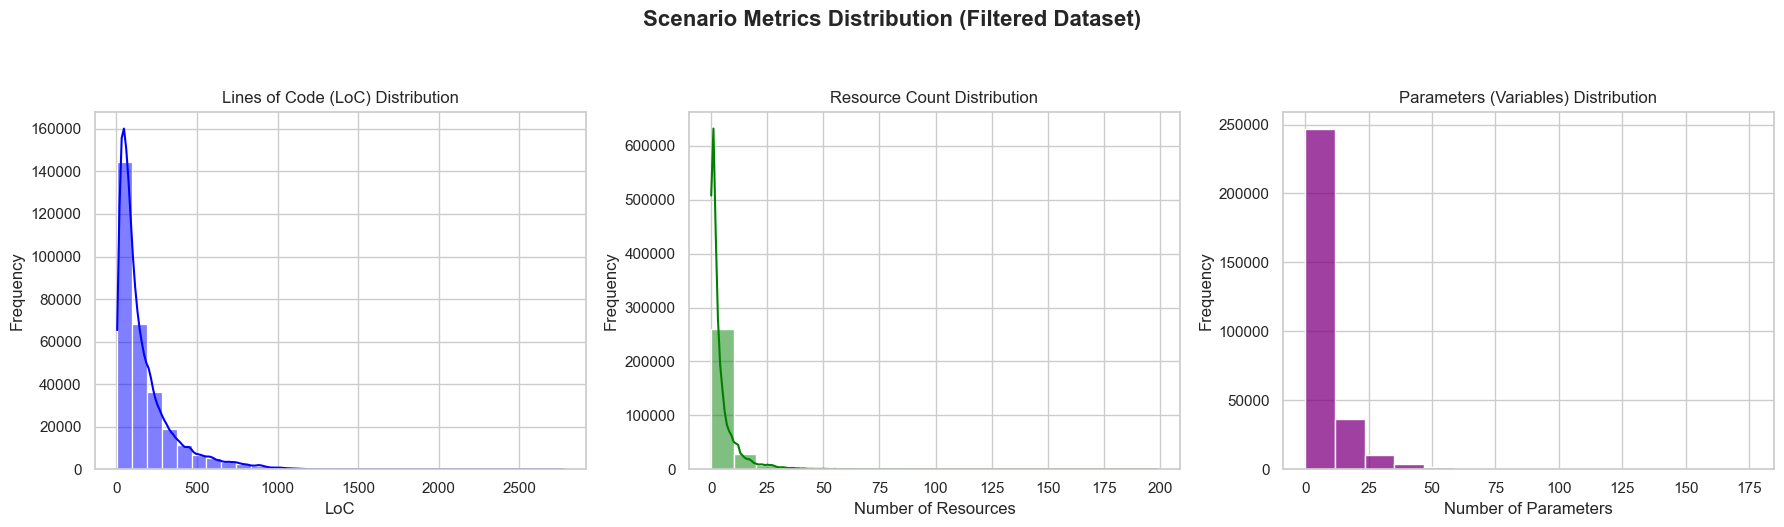

In [12]:
# %%
# ── 8. Count, Filter, and AST Parsing (Unix OS-Level Timeout) ─────────────────
import hcl2
import io
import re
import os
import pathlib
import signal
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PARSE_CACHE_FILE = DATASET_DIR / 'ast_parse_cache.csv'
VERBOSE_PARSE_LOGS = False
PROGRESS_EVERY = 25

# ── 1. Load Cache (Memory Efficient) ──────────────────────────────────────────
file_has_header = PARSE_CACHE_FILE.exists()

if file_has_header:
    df_cache_ids = pd.read_csv(PARSE_CACHE_FILE, usecols=['scenario_id'])
    processed_ids = set(df_cache_ids['scenario_id'])
    print(f'✅ Loaded {len(processed_ids)} previously parsed scenario IDs from cache.')
else:
    processed_ids = set()

# ── 2. Filter Unprocessed Scenarios ───────────────────────────────────────────
scenarios_to_process = [rec for rec in raw_scenarios if rec['scenario_id'] not in processed_ids]
print(f'Calculating LoC, tokens, and AST features for {len(scenarios_to_process)} new scenarios...')

# ── OS-Level Timeout Setup ────────────────────────────────────────────────────
class TimeoutException(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutException("Parser timed out!")

def parse_hcl2_safe(content, timeout_sec=2):
    """Uses Unix signals to forcefully interrupt catastrophic parsing deadlocks."""
    if len(content.encode('utf-8')) > 150_000:
        return None

    old_handler = signal.signal(signal.SIGALRM, timeout_handler)
    signal.alarm(timeout_sec)

    try:
        return hcl2.load(io.StringIO(content))
    except TimeoutException:
        return None
    except Exception:
        return None
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old_handler)

# ── 3. Parse and Periodically Save (Append Mode) ──────────────────────────────
new_count = 0
batch_data = []

# Pre-compile regex
RE_RESOURCE = re.compile(r'^\s*resource\s+"', re.MULTILINE)
RE_VARIABLE = re.compile(r'^\s*variable\s+"', re.MULTILINE)

for rec in scenarios_to_process:
    scenario_id = rec['scenario_id']
    folder = pathlib.Path(rec['folder_path'])
    tf_files = list(folder.glob('*.tf'))

    if VERBOSE_PARSE_LOGS or (new_count % PROGRESS_EVERY == 0):
        print(f"[{new_count + 1}/{len(scenarios_to_process)}] Processing {scenario_id} ({len(tf_files)} files)")

    # Merge content
    merged_content = "\n\n".join(f.read_text(encoding='utf-8', errors='ignore') for f in tf_files)
    loc = merged_content.count('\n') + 1

    # Tokenizer step
    if len(merged_content) > 1_000_000:
        tokens = 999_999
    else:
        try:
            tokens = len(TOKENIZER.encode(merged_content))
        except Exception:
            tokens = 0

    n_res = 0
    n_var = 0
    file_errors = 0

    # Parse each file
    for f in tf_files:
        content = f.read_text(encoding='utf-8', errors='ignore')
        ast = parse_hcl2_safe(content, timeout_sec=2)

        if ast is not None:
            n_res += sum(len(v) for k, v in ast.items() if k == "resource")
            n_var += sum(len(v) for k, v in ast.items() if k == "variable")
        else:
            file_errors += 1
            try:
                n_res += len(RE_RESOURCE.findall(content))
                n_var += len(RE_VARIABLE.findall(content))
            except Exception:
                file_errors += 1

    batch_data.append({
        'scenario_id': scenario_id,
        'source': rec['source'],
        'folder_path': rec['folder_path'],
        'loc': loc,
        'tokens': tokens,
        'n_resources': n_res,
        'n_params': n_var
    })

    new_count += 1
    processed_ids.add(scenario_id)

    if new_count % PROGRESS_EVERY == 0:
        print(f"  -> processed {new_count}/{len(scenarios_to_process)} scenarios; cache size={len(processed_ids)}")

    # Flush to disk every 50 records
    if new_count % 50 == 0:
        df_batch = pd.DataFrame(batch_data)
        df_batch.to_csv(PARSE_CACHE_FILE, mode='a', header=not file_has_header, index=False)
        file_has_header = True
        batch_data.clear()
        print(f'💾 Cache saved: {len(processed_ids)} scenarios processed')

# Final save
if batch_data:
    df_batch = pd.DataFrame(batch_data)
    df_batch.to_csv(PARSE_CACHE_FILE, mode='a', header=not file_has_header, index=False)
    batch_data.clear()
    print(f'✅ Finished parsing and saved all {len(processed_ids)} scenarios to cache.')

# ── 4. Load Everything for Filtering & Visualization ──────────────────────────
df_all = pd.read_csv(PARSE_CACHE_FILE)
df_filtered = df_all[(df_all['loc'] >= MIN_LOC) & (df_all['tokens'] <= MAX_TOKENS)].copy()

print('\nFiltering Results:')
print(f'  Original count : {len(df_all)}')
print(f'  Filtered count : {len(df_filtered)} (dropped {len(df_all) - len(df_filtered)})')

# ── 5. Visualizations ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scenario Metrics Distribution (Filtered Dataset)', fontsize=16, fontweight='bold', y=1.05)

sns.histplot(df_filtered['loc'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Lines of Code (LoC) Distribution')
axes[0].set_xlabel('LoC')
axes[0].set_ylabel('Frequency')

sns.histplot(df_filtered['n_resources'], bins=20, kde=True, ax=axes[1], color='green')
axes[1].set_title('Resource Count Distribution')
axes[1].set_xlabel('Number of Resources')
axes[1].set_ylabel('Frequency')

sns.histplot(df_filtered['n_params'], bins=15, kde=False, ax=axes[2], color='purple')
axes[2].set_title('Parameters (Variables) Distribution')
axes[2].set_xlabel('Number of Parameters')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [13]:
# %%
# ── 9. Load from Cache & Difficulty Analysis (Bypassing Parser) ───────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

PARSE_CACHE_FILE = DATASET_DIR / 'ast_parse_cache.csv'

# ── 1. Load Data Directly From Cache ──────────────────────────────────────────
if PARSE_CACHE_FILE.exists():
    df_all = pd.read_csv(PARSE_CACHE_FILE)
    print(f'✅ Successfully loaded {len(df_all)} scenarios directly from cache!')
else:
    raise FileNotFoundError(f"Cache file not found at {PARSE_CACHE_FILE}. Cannot proceed without data.")

# ── 2. Apply Filters ──────────────────────────────────────────────────────────
df_filtered = df_all[(df_all['loc'] >= MIN_LOC) & (df_all['tokens'] <= MAX_TOKENS)].copy()

print(f'\nFiltering Results:')
print(f'  Original count : {len(df_all)}')
print(f'  Filtered count : {len(df_filtered)} (dropped {len(df_all) - len(df_filtered)})')

✅ Successfully loaded 311036 scenarios directly from cache!

Filtering Results:
  Original count : 311036
  Filtered count : 300642 (dropped 10394)


In [14]:
# %%
# ── Utility: Clean TFLint Cache (Remove Warning-Only Rows) ────────────────────
import pandas as pd
from pathlib import Path

# Adjust this path if your DATASET_DIR is defined differently in this isolated cell
DATASET_DIR = Path('./iac_benchmark/dataset') 
TFLINT_CACHE_FILE = DATASET_DIR / 'tflint_cache.csv'

if TFLINT_CACHE_FILE.exists():
    df_cache = pd.read_csv(TFLINT_CACHE_FILE)
    original_count = len(df_cache)
    
    def has_only_warnings(log_text):
        if not isinstance(log_text, str) or not log_text.strip():
            return False
            
        text_upper = log_text.upper()
        has_warn = 'WARNING:' in text_upper
        has_err = 'ERROR' in text_upper or 'SYSTEM ERROR' in text_upper or 'TIMEOUT' in text_upper
        
        # Return True if it contains warnings/notices but NO hard errors
        return has_warn and not has_err

    # Keep rows that do NOT match the warning-only criteria
    mask_to_keep = ~df_cache['tflint_log'].apply(has_only_warnings)
    df_cleaned = df_cache[mask_to_keep].copy()
    
    # Save the cleaned cache back to disk
    df_cleaned.to_csv(TFLINT_CACHE_FILE, index=False)
    
    dropped_count = original_count - len(df_cleaned)
    print(f"🧹 TFLint cache cleaned successfully!")
    print(f"  -> Original rows : {original_count}")
    print(f"  -> Dropped rows  : {dropped_count} (warning-only logs)")
    print(f"  -> New cache size: {len(df_cleaned)}\n")
    print("Next step: Re-run Cell 11 to re-evaluate the dropped scenarios with the clean logic.")
else:
    print(f"⚠️ Cache file not found at {TFLINT_CACHE_FILE}")

🧹 TFLint cache cleaned successfully!
  -> Original rows : 27015
  -> Dropped rows  : 17248 (warning-only logs)
  -> New cache size: 9767

Next step: Re-run Cell 11 to re-evaluate the dropped scenarios with the clean logic.


In [15]:
# %%
# ── 10. Assign Difficulty and Oversample New Scenarios ────────────────────────
import pandas as pd
import numpy as np

EXPORT_PATH = DATASET_DIR / 'validation_pipeline_batch.csv'

# Use TFLINT cache as the absolute history of everything we've EVER evaluated
TFLINT_CACHE_PATH = DATASET_DIR / 'tflint_cache.csv'

# ── 0. Exclude Previously Sampled Scenarios ───────────────────────────────────
if TFLINT_CACHE_PATH.exists():
    df_prev = pd.read_csv(TFLINT_CACHE_PATH)
    excluded_ids = set(df_prev['scenario_id'])
    print(f"Loaded {len(excluded_ids)} previously evaluated scenarios to exclude.")
else:
    excluded_ids = set()
    print("No evaluation history found. Starting fresh.")

# Remove the excluded IDs from the pool
df_fresh_candidates = df_filtered[~df_filtered['scenario_id'].isin(excluded_ids)].copy()

# ── 1. The Discard Pile ───────────────────────────────────────────────────────
df_hard = df_fresh_candidates[
    (df_fresh_candidates['loc'] >= 30) & 
    (df_fresh_candidates['n_resources'] >= 2)
].copy()

print(f"Dropped trivial scenarios. Remaining fresh candidates: {len(df_hard)}")

# ── 2. Assign Difficulty Levels ───────────────────────────────────────────────
def calculate_difficulty(row):
    loc = row['loc']
    res = row['n_resources']
    if loc >= 400 and res >= 12: return 5
    elif loc >= 250 and res >= 8: return 4
    elif loc >= 150 and res >= 4: return 3
    elif loc >= 80: return 2
    else: return 1

if not df_hard.empty:
    df_hard['difficulty'] = df_hard.apply(calculate_difficulty, axis=1)

# ── 3. Balanced Oversampling ──────────────────────────────────────────────────
TARGET_SAMPLE_PER_LEVEL = 10000
sampled_dfs = []

for level in range(1, 6):
    level_df = df_hard[df_hard['difficulty'] == level]
    n_available = len(level_df)
    if n_available == 0:
        continue
    n_to_sample = min(TARGET_SAMPLE_PER_LEVEL, n_available)
    sampled_dfs.append(level_df.sample(n=n_to_sample, random_state=42))
    print(f"Level {level}: Sampled {n_to_sample} new scenarios out of {n_available} available.")

# ── 4. Export the Active Queue ────────────────────────────────────────────────
if sampled_dfs:
    df_new_batch = pd.concat(sampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
    # ONLY save the newly sampled scenarios to the pipeline batch
    df_new_batch.to_csv(EXPORT_PATH, index=False)
    print(f"\n✅ Created fresh validation batch of {len(df_new_batch)} scenarios.")
    print(f"📁 Active queue saved to: {EXPORT_PATH}")
else:
    print("\n✅ No new scenarios available to sample.")

Loaded 9767 previously evaluated scenarios to exclude.
Dropped trivial scenarios. Remaining fresh candidates: 159310
Level 1: Sampled 10000 new scenarios out of 37729 available.
Level 2: Sampled 10000 new scenarios out of 54288 available.
Level 3: Sampled 10000 new scenarios out of 38153 available.
Level 4: Sampled 10000 new scenarios out of 16813 available.
Level 5: Sampled 10000 new scenarios out of 12327 available.

✅ Created fresh validation batch of 50000 scenarios.
📁 Active queue saved to: iac_benchmark/dataset/validation_pipeline_batch.csv


In [17]:
# %%
# ── 11. TFLint Validation (With Formatted Logs & Warning Ignore) ──────────────
import json
import shutil
import tempfile
import subprocess
import pandas as pd
from pathlib import Path

INPUT_CSV = DATASET_DIR / 'validation_pipeline_batch.csv'
TFLINT_CACHE_FILE = DATASET_DIR / 'tflint_cache.csv'
TFLINT_PASSED_CSV = DATASET_DIR / 'tflint_passed_batch.csv'
PROGRESS_EVERY = 25

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Input batch not found at {INPUT_CSV}")

df_input = pd.read_csv(INPUT_CSV)

# ── 1. Load Cache ─────────────────────────────────────────────────────────────
if TFLINT_CACHE_FILE.exists():
    df_cache = pd.read_csv(TFLINT_CACHE_FILE)
    processed_ids = set(df_cache['scenario_id'])
    results = df_cache.to_dict('records')
    print(f"✅ Loaded {len(processed_ids)} previously TFLint-scanned scenarios.")
else:
    processed_ids = set()
    results = []

scenarios_to_process = [row.to_dict() for _, row in df_input.iterrows() if row['scenario_id'] not in processed_ids]
print(f"Running TFLint on {len(scenarios_to_process)} unchecked scenarios...")

# ── Helper: Truncate Raw Logs ─────────────────────────────────────────────────
def truncate_log(raw_text, max_len=1500):
    if not raw_text: return ""
    clean = str(raw_text).strip()
    if len(clean) > max_len: 
        return clean[:(max_len//2)] + "\n\n...[LOG TRUNCATED]...\n\n" + clean[-(max_len//2):]
    return clean

# ── 2. Run TFLint ─────────────────────────────────────────────────────────────
new_count = 0
for rec in scenarios_to_process:
    folder_path = Path(rec['folder_path'])
    tflint_log = ""
    
    with tempfile.TemporaryDirectory() as tmpdir:
        tmp_path = Path(tmpdir)
        for f in folder_path.glob('*.tf'):
            shutil.copy2(f, tmp_path / f.name)
            
        try:
            # Init phase (downloads AWS provider ruleset)
            subprocess.run(
                ["tflint", "--init", "--no-color"], 
                cwd=tmpdir, capture_output=True, timeout=120, shell=True, env=env
            )
            
            # Lint phase
            lint_result = subprocess.run(
                ["tflint", "--format", "json", "--no-color"], 
                cwd=tmpdir, capture_output=True, text=True, timeout=60, shell=True, env=env
            )
            raw_out = lint_result.stdout or lint_result.stderr
            error_severity_count = 0
            log_lines = []
            
            try:
                data = json.loads(raw_out)
                for issue in data.get("issues", []):
                    rule = issue.get("rule", {})
                    severity = rule.get("severity", "error").lower()
                    
                    # Completely ignore warnings and notices
                    if severity != "error":
                        continue
                        
                    rule_id = rule.get("name", "?")
                    message = (issue.get("message") or "").strip()
                    line_num = issue.get("range", {}).get("start", {}).get("line")

                    # Format: [rule_id] [SEVERITY] line N | message
                    parts = [f"[{rule_id}]", f"[{severity.upper()}]"]
                    if line_num: parts.append(f"line {line_num}")
                    if message: parts.append(message)
                    log_lines.append(" | ".join(parts))

                    error_severity_count += 1
                        
                tflint_passed = (error_severity_count == 0)
                tflint_log = "\n".join(log_lines)
                
            except json.JSONDecodeError:
                # Fallback if TFLint crashes and spits out raw text instead of JSON
                tflint_passed = (lint_result.returncode == 0)
                tflint_log = f"NON-JSON OUTPUT:\n{truncate_log(raw_out)}"
                
        except subprocess.TimeoutExpired:
            tflint_passed = False
            tflint_log = "TIMEOUT: TFLint took longer than 60 seconds."
        except Exception as e:
            tflint_passed = False
            tflint_log = f"SYSTEM ERROR: {str(e)}"

    rec['tflint_passed'] = tflint_passed
    rec['tflint_log'] = tflint_log
    
    results.append(rec)
    processed_ids.add(rec['scenario_id'])
    new_count += 1
    
    if new_count % PROGRESS_EVERY == 0:
        print(f"  -> processed {new_count}/{len(scenarios_to_process)} scenarios")
    if new_count % 50 == 0:
        pd.DataFrame(results).to_csv(TFLINT_CACHE_FILE, index=False)

# ── 3. Final Save & Filter ────────────────────────────────────────────────────
df_results = pd.DataFrame(results)
if not df_results.empty:
    df_results.to_csv(TFLINT_CACHE_FILE, index=False)
    df_tflint_passed = df_results[df_results['tflint_passed'] == True].copy()
    df_tflint_passed.to_csv(TFLINT_PASSED_CSV, index=False)
    print(f"\n✅ TFLint complete. Cumulative Passed: {len(df_tflint_passed)} / {len(df_results)}")

✅ Loaded 15367 previously TFLint-scanned scenarios.
Running TFLint on 44400 unchecked scenarios...
  -> processed 25/44400 scenarios
  -> processed 50/44400 scenarios
  -> processed 75/44400 scenarios
  -> processed 100/44400 scenarios
  -> processed 125/44400 scenarios
  -> processed 150/44400 scenarios
  -> processed 175/44400 scenarios
  -> processed 200/44400 scenarios
  -> processed 225/44400 scenarios
  -> processed 250/44400 scenarios
  -> processed 275/44400 scenarios
  -> processed 300/44400 scenarios
  -> processed 325/44400 scenarios
  -> processed 350/44400 scenarios
  -> processed 375/44400 scenarios
  -> processed 400/44400 scenarios
  -> processed 425/44400 scenarios
  -> processed 450/44400 scenarios
  -> processed 475/44400 scenarios
  -> processed 500/44400 scenarios
  -> processed 525/44400 scenarios
  -> processed 550/44400 scenarios
  -> processed 575/44400 scenarios
  -> processed 600/44400 scenarios
  -> processed 625/44400 scenarios
  -> processed 650/44400 scen

In [18]:
# %%
# ── 12. Trivy Security Scanning ───────────────────────────────────────────────
import json
import shutil
import tempfile
import subprocess
import pandas as pd
from pathlib import Path

INPUT_CSV = DATASET_DIR / 'tflint_passed_batch.csv'
TRIVY_CACHE_FILE = DATASET_DIR / 'trivy_cache.csv'
TRIVY_SCANNED_CSV = DATASET_DIR / 'trivy_scanned_batch.csv'
PROGRESS_EVERY = 25

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Input batch not found at {INPUT_CSV}")

df_input = pd.read_csv(INPUT_CSV)

# ── 1. Load Cache ─────────────────────────────────────────────────────────────
if TRIVY_CACHE_FILE.exists():
    df_cache = pd.read_csv(TRIVY_CACHE_FILE)
    processed_ids = set(df_cache['scenario_id'])
    results = df_cache.to_dict('records')
    print(f"✅ Loaded {len(processed_ids)} previously Trivy-scanned scenarios.")
else:
    processed_ids = set()
    results = []

scenarios_to_process = [row.to_dict() for _, row in df_input.iterrows() if row['scenario_id'] not in processed_ids]
print(f"Running Trivy on {len(scenarios_to_process)} unchecked scenarios...")

# ── 2. Run Trivy ──────────────────────────────────────────────────────────────
new_count = 0
for rec in scenarios_to_process:
    folder_path = Path(rec['folder_path'])
    
    with tempfile.TemporaryDirectory() as tmpdir:
        tmp_path = Path(tmpdir)
        for f in folder_path.glob('*.tf'):
            shutil.copy2(f, tmp_path / f.name)
            
        try:
            result = subprocess.run(["trivy", "config", "--format", "json", str(tmpdir)], capture_output=True, text=True, timeout=120, shell=True, env=env)
            raw = result.stdout or result.stderr
            counts = {"critical": 0, "high": 0, "medium": 0, "low": 0, "unknown": 0}
            
            try:
                data = json.loads(raw)
                for r in data.get("Results", []):
                    for m in r.get("Misconfigurations", []):
                        sev = m.get("Severity", "").lower()
                        if sev in counts: counts[sev] += 1
                        else: counts["unknown"] += 1
                trivy_scan_success = True
            except json.JSONDecodeError:
                trivy_scan_success = (result.returncode == 0)
        except Exception:
            trivy_scan_success = False
            counts = {"critical": 0, "high": 0, "medium": 0, "low": 0, "unknown": 0}

    rec['trivy_scan_success'] = trivy_scan_success
    for sev_level, count in counts.items():
        rec[f'trivy_{sev_level}'] = count

    results.append(rec)
    processed_ids.add(rec['scenario_id'])
    new_count += 1
    
    if new_count % PROGRESS_EVERY == 0:
        print(f"  -> processed {new_count}/{len(scenarios_to_process)} scenarios")
    if new_count % 50 == 0:
        pd.DataFrame(results).to_csv(TRIVY_CACHE_FILE, index=False)

# ── 3. Final Save & Filter ────────────────────────────────────────────────────
df_results = pd.DataFrame(results)
if not df_results.empty:
    df_results.to_csv(TRIVY_CACHE_FILE, index=False)
    df_trivy_scanned = df_results[df_results['trivy_scan_success'] == True].copy()
    df_trivy_scanned.to_csv(TRIVY_SCANNED_CSV, index=False)
    print(f"\n✅ Trivy complete. Successfully Scanned: {len(df_trivy_scanned)} / {len(df_results)}")

✅ Loaded 4997 previously Trivy-scanned scenarios.
Running Trivy on 4356 unchecked scenarios...
  -> processed 25/4356 scenarios
  -> processed 50/4356 scenarios
  -> processed 75/4356 scenarios
  -> processed 100/4356 scenarios
  -> processed 125/4356 scenarios
  -> processed 150/4356 scenarios
  -> processed 175/4356 scenarios
  -> processed 200/4356 scenarios
  -> processed 225/4356 scenarios
  -> processed 250/4356 scenarios
  -> processed 275/4356 scenarios
  -> processed 300/4356 scenarios
  -> processed 325/4356 scenarios
  -> processed 350/4356 scenarios
  -> processed 375/4356 scenarios
  -> processed 400/4356 scenarios
  -> processed 425/4356 scenarios
  -> processed 450/4356 scenarios
  -> processed 475/4356 scenarios
  -> processed 500/4356 scenarios
  -> processed 525/4356 scenarios
  -> processed 550/4356 scenarios
  -> processed 575/4356 scenarios
  -> processed 600/4356 scenarios
  -> processed 625/4356 scenarios
  -> processed 650/4356 scenarios
  -> processed 675/4356 

In [19]:
# %%
# ── 12.5. Filter by Trivy Severity ────────────────────────────────────────────
import pandas as pd

TRIVY_SCANNED_CSV = DATASET_DIR / 'trivy_scanned_batch.csv'
TRIVY_FILTERED_CSV = DATASET_DIR / 'trivy_filtered_batch.csv'

if not TRIVY_SCANNED_CSV.exists():
    raise FileNotFoundError(f"Trivy scanned batch not found at {TRIVY_SCANNED_CSV}")

df_trivy = pd.read_csv(TRIVY_SCANNED_CSV)

# ── Customisable Severity Filter ──
DISALLOWED_SEVERITIES = ["critical", "high", "medium"]
print(f"Filtering out scenarios containing ANY of these severities: {DISALLOWED_SEVERITIES}")

mask = pd.Series([True] * len(df_trivy), index=df_trivy.index)
for sev in DISALLOWED_SEVERITIES:
    col_name = f'trivy_{sev}'
    if col_name in df_trivy.columns:
        mask = mask & (df_trivy[col_name] == 0)

df_trivy_filtered = df_trivy[mask].copy()
df_trivy_filtered.to_csv(TRIVY_FILTERED_CSV, index=False)

print(f"✅ Filter complete. Kept {len(df_trivy_filtered)} / {len(df_trivy)} secure scenarios.")

Filtering out scenarios containing ANY of these severities: ['critical', 'high', 'medium']
✅ Filter complete. Kept 8139 / 9345 secure scenarios.


In [30]:
subprocess.run("tflocal", shell=True, env=run_env)

Usage: terraform [global options] <subcommand> [args]

The available commands for execution are listed below.
The primary workflow commands are given first, followed by
less common or more advanced commands.

Main commands:
  init          Prepare your working directory for other commands
  validate      Check whether the configuration is valid
  plan          Show changes required by the current configuration
  apply         Create or update infrastructure
  destroy       Destroy previously-created infrastructure

All other commands:
  console       Try Terraform expressions at an interactive command prompt
  fmt           Reformat your configuration in the standard style
  force-unlock  Release a stuck lock on the current workspace
  get           Install or upgrade remote Terraform modules
  graph         Generate a Graphviz graph of the steps in an operation
  import        Associate existing infrastructure with a Terraform resource
  login         Obtain and save credentials for a

CompletedProcess(args='tflocal', returncode=127)

In [32]:
# %%
# ── 13. LocalStack Deployability Testing (Optimized Caching + Logs) ───────────
import os
import re
import shutil
import tempfile
import subprocess
import pandas as pd
from pathlib import Path

INPUT_CSV = DATASET_DIR / 'trivy_filtered_batch.csv'
DEPLOY_CACHE_FILE = DATASET_DIR / 'deploy_cache.csv'
DEPLOY_PASSED_CSV = DATASET_DIR / 'deploy_passed_batch.csv'

TF_PLUGIN_CACHE_DIR = (BASE_DIR / ".tf_plugin_cache").resolve()
TF_PLUGIN_CACHE_DIR.mkdir(parents=True, exist_ok=True)
PROGRESS_EVERY = 25
STORE_FULL_DEPLOY_LOGS = True  # Set to False to only store logs for failed deployments

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Input batch not found at {INPUT_CSV}")

df_input = pd.read_csv(INPUT_CSV)

# ── 1. Load Cache ─────────────────────────────────────────────────────────────
if DEPLOY_CACHE_FILE.exists():
    df_cache = pd.read_csv(DEPLOY_CACHE_FILE)
    processed_ids = set(df_cache['scenario_id'])
    results = df_cache.to_dict('records')
    print(f"✅ Loaded {len(processed_ids)} previously deployed scenarios.")
else:
    processed_ids = set()
    results = []

scenarios_to_process = [row.to_dict() for _, row in df_input.iterrows() if row['scenario_id'] not in processed_ids]
print(f"Deploying {len(scenarios_to_process)} unchecked scenarios to LocalStack...\n")

# ── 2. Pre-Warm the Provider Cache ────────────────────────────────────────────
run_env = os.environ.copy()
run_env.update({
    "AWS_ACCESS_KEY_ID": "test",
    "AWS_SECRET_ACCESS_KEY": "test",
    "AWS_DEFAULT_REGION": "us-east-1",
    "TF_PLUGIN_CACHE_DIR": str(TF_PLUGIN_CACHE_DIR),
    "PATH": f"/opt/homebrew/bin:{run_env['PATH']}"
})

if len(scenarios_to_process) > 0:
    print("Pre-warming AWS provider cache...")
    with tempfile.TemporaryDirectory() as warmup_dir:
        (Path(warmup_dir) / "main.tf").write_text('provider "aws" { region = "us-east-1" }')
        # Removed shell=True so the list arguments actually execute!
        subprocess.run(["tflocal", "init", "-backend=false", "-input=false", "-no-color"], cwd=warmup_dir, capture_output=True, env=run_env)
    print("✅ Cache warmed up! Starting deployments...\n")

def format_log(raw_text):
    if not raw_text: return ""
    clean = re.sub(r'\x1b\[[0-9;]*[a-zA-Z]', '', raw_text)
    clean = re.sub(r'\n{3,}', '\n\n', clean).strip()
    if len(clean) > 1200: return clean[:600] + "\n\n...[LOG TRUNCATED]...\n\n" + clean[-600:]
    return clean

# ── 3. Run Deployments ────────────────────────────────────────────────────────
new_count = 0
for rec in scenarios_to_process:
    folder_path = Path(rec['folder_path'])
    scenario_id = rec['scenario_id']
    deploy_passed = False
    init_log, apply_log, err_log = "", "", ""

    if new_count % PROGRESS_EVERY == 0:
        print(f"[{new_count + 1}/{len(scenarios_to_process)}] {scenario_id}")

    with tempfile.TemporaryDirectory() as tmpdir:
        tmp_path = Path(tmpdir)
        for f in folder_path.glob('*.tf'):
            shutil.copy2(f, tmp_path / f.name)

        try:
            # Removed shell=True from all subprocess calls
            init_res = subprocess.run(["tflocal", "init", "-backend=false", "-input=false", "-no-color"], cwd=tmpdir, capture_output=True, text=True, timeout=5*60, env=run_env)
            init_log = init_res.stdout + "\n" + init_res.stderr

            if init_res.returncode == 0:
                apply_res = subprocess.run(["tflocal", "apply", "-auto-approve", "-input=false", "-no-color"], cwd=tmpdir, capture_output=True, text=True, timeout=10*60, env=run_env)
                apply_log = apply_res.stdout + "\n" + apply_res.stderr
                if apply_res.returncode == 0:
                    deploy_passed = True
                
                subprocess.run(["tflocal", "destroy", "-auto-approve", "-input=false", "-no-color"], cwd=tmpdir, capture_output=True, text=True, timeout=5*60, env=run_env)
        except subprocess.TimeoutExpired as e:
            cmd_name = e.cmd[1] if len(e.cmd) > 1 else "unknown"
            err_log = f"TIMEOUT: Command '{cmd_name}' exceeded time limit."
        except Exception as e:
            err_log = f"SYSTEM ERROR: {str(e)}"

    combined_log = f"--- INIT LOG ---\n{init_log}\n\n--- APPLY LOG ---\n{apply_log}\n\n--- ERRORS ---\n{err_log}".strip()
    rec['deploy_passed'] = deploy_passed
    rec['deploy_log'] = format_log(combined_log) if (STORE_FULL_DEPLOY_LOGS or not deploy_passed) else ""
    
    # Clean debug output directly in the cell
    print(f"  -> passed={deploy_passed}")
    if not deploy_passed:
        print(f"\n{'='*60}\n🚨 DEBUG LOG FOR {scenario_id}:\n{rec['deploy_log']}\n{'='*60}\n")

    results.append(rec)
    processed_ids.add(scenario_id)
    new_count += 1

    pd.DataFrame(results).to_csv(DEPLOY_CACHE_FILE, index=False)

# ── 4. Final Save & Filter ────────────────────────────────────────────────────
df_results = pd.DataFrame(results)
if not df_results.empty:
    df_results.to_csv(DEPLOY_CACHE_FILE, index=False)
    df_deploy_passed = df_results[df_results['deploy_passed'] == True].copy()
    df_deploy_passed.to_csv(DEPLOY_PASSED_CSV, index=False)
    print(f"\n✅ LocalStack deploy complete. Cumulative Deployable: {len(df_deploy_passed)} / {len(df_results)}")

✅ Loaded 33 previously deployed scenarios.
Deploying 8119 unchecked scenarios to LocalStack...

Pre-warming AWS provider cache...
✅ Cache warmed up! Starting deployments...

[1/8119] gh_9f8d1fbd
  -> passed=False

🚨 DEBUG LOG FOR gh_9f8d1fbd:
--- INIT LOG ---
Initializing modules...
- diagnostics in
- private_endpoint in

Error: Unreadable module directory

Unable to evaluate directory symlink: lstat ../diagnostics: no such file or
directory

Error: Unreadable module directory

The directory  could not be read for module "diagnostics" at
diagnostics.tf:2.

Error: Unreadable module directory

Unable to evaluate directory symlink: lstat ../networking: no such file or
directory

Error: Unreadable module directory

The directory  could not be read for module "private_endpoint" at
private_endpoints.tf:7.

--- APPLY LOG ---

--- ERRORS ---

  -> passed=False

🚨 DEBUG LOG FOR gh_8a88d57c:
--- INIT LOG ---
Initializing provider plugins...
- Finding latest version of hashicorp/elasticstack...
-

KeyboardInterrupt: 

Loaded 26 successfully deployed scenarios.

Deployable Distribution Before Balancing:
difficulty
1    7
2    6
3    7
4    6
Name: count, dtype: int64

Sampling for final benchmark...
  ⚠️ Level 1: Only 7 deployable scenarios found (Target: 40).
  ⚠️ Level 2: Only 6 deployable scenarios found (Target: 40).
  ⚠️ Level 3: Only 7 deployable scenarios found (Target: 40).
  ⚠️ Level 4: Only 6 deployable scenarios found (Target: 40).
  ⚠️ Level 5: No scenarios available!



🎉 Final balanced benchmark created with 26 scenarios!
📁 Saved to: iac_benchmark/dataset/final_benchmark_balanced.csv



/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_22221/3413217520.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='difficulty', ax=axes[0], palette='viridis')
/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_22221/3413217520.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='difficulty', y='loc', ax=axes[1], palette='viridis')
/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_22221/3413217520.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='difficu

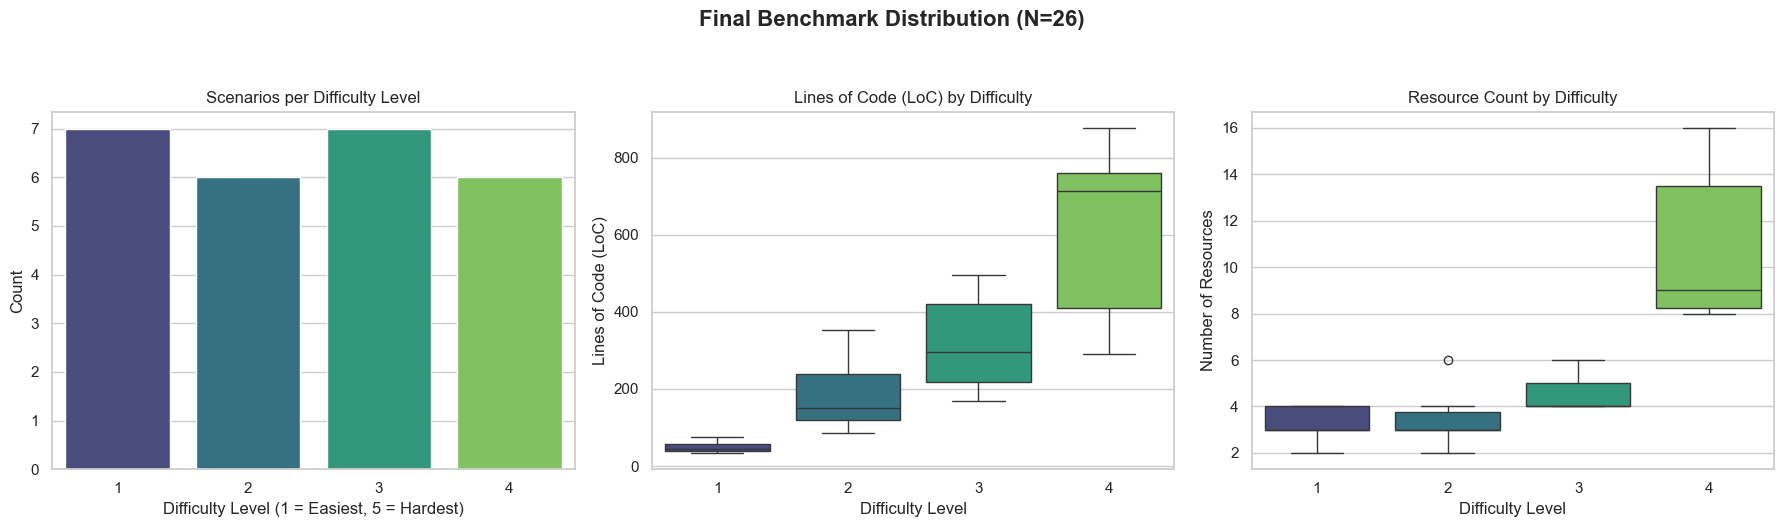

Median Statistics by Difficulty Level:


,Median LoC,Median Resources,Median Params
difficulty,,,
1,44.0,3.0,0.0
2,150.0,3.0,9.0
3,296.0,4.0,8.0
4,714.5,9.0,46.0


In [35]:
# %%
# ── 14. Final Benchmark Assembly & Visualisation ──────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DEPLOY_PASSED_CSV = DATASET_DIR / 'deploy_passed_batch.csv'
FINAL_BENCHMARK_CSV = DATASET_DIR / 'final_benchmark_balanced.csv'

if not DEPLOY_PASSED_CSV.exists():
    raise FileNotFoundError(f"Deployable batch not found at {DEPLOY_PASSED_CSV}")

df_deployable = pd.read_csv(DEPLOY_PASSED_CSV)
print(f"Loaded {len(df_deployable)} successfully deployed scenarios.")

print("\nDeployable Distribution Before Balancing:")
print(df_deployable['difficulty'].value_counts().sort_index())

# ── 1. Balance to Target Size (~200 total, 40 per level) ────────────────────
TARGET_PER_LEVEL = 40
sampled_dfs = []

print("\nSampling for final benchmark...")
for level in range(1, 6):
    level_df = df_deployable[df_deployable['difficulty'] == level]
    n_avail = len(level_df)
    
    if n_avail == 0:
        print(f"  ⚠️ Level {level}: No scenarios available!")
        continue
        
    n_to_sample = min(TARGET_PER_LEVEL, n_avail)
    
    # Sample randomly to ensure unbiased selection
    sampled = level_df.sample(n=n_to_sample, random_state=42)
    sampled_dfs.append(sampled)
    
    if n_to_sample < TARGET_PER_LEVEL:
        print(f"  ⚠️ Level {level}: Only {n_avail} deployable scenarios found (Target: {TARGET_PER_LEVEL}).")
    else:
        print(f"  ✅ Level {level}: Sampled exactly {n_to_sample} scenarios.")

df_final = pd.concat(sampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# ── 2. Save Final Benchmark ───────────────────────────────────────────────────
df_final.to_csv(FINAL_BENCHMARK_CSV, index=False)
print(f"\n🎉 Final balanced benchmark created with {len(df_final)} scenarios!")
print(f"📁 Saved to: {FINAL_BENCHMARK_CSV}\n")

# ── 3. Visualisations ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Final Benchmark Distribution (N={len(df_final)})', fontsize=16, fontweight='bold', y=1.05)

# Plot 1: Count per Difficulty
sns.countplot(data=df_final, x='difficulty', ax=axes[0], palette='viridis')
axes[0].set_title('Scenarios per Difficulty Level')
axes[0].set_xlabel('Difficulty Level (1 = Easiest, 5 = Hardest)')
axes[0].set_ylabel('Count')

# Plot 2: LoC by Difficulty (Boxplot to show variance)
sns.boxplot(data=df_final, x='difficulty', y='loc', ax=axes[1], palette='viridis')
axes[1].set_title('Lines of Code (LoC) by Difficulty')
axes[1].set_xlabel('Difficulty Level')
axes[1].set_ylabel('Lines of Code (LoC)')

# Plot 3: Resources by Difficulty
sns.boxplot(data=df_final, x='difficulty', y='n_resources', ax=axes[2], palette='viridis')
axes[2].set_title('Resource Count by Difficulty')
axes[2].set_xlabel('Difficulty Level')
axes[2].set_ylabel('Number of Resources')

plt.tight_layout()
plt.show()

# ── 4. Median Summary Table ───────────────────────────────────────────────────
print("Median Statistics by Difficulty Level:")
summary_table = df_final.groupby('difficulty')[['loc', 'n_resources', 'n_params']].median().round(1).rename(columns={
    'loc': 'Median LoC',
    'n_resources': 'Median Resources',
    'n_params': 'Median Params'
})
display(summary_table)